# Persiapan

In [1]:
!pip install -q scikit-learn xgboost joblib

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, recall_score, precision_score, accuracy_score, roc_auc_score,
)

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print("XGBoost tidak tersedia, akan dilewati.")

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)


Data

In [3]:
from google.colab import files

uploaded = files.upload()
DATA_PATH = list(uploaded.keys())[0]
print("File yang diupload:", DATA_PATH)

Saving Bank Customer Churn Prediction.csv to Bank Customer Churn Prediction.csv
File yang diupload: Bank Customer Churn Prediction.csv


In [4]:
df = pd.read_csv(DATA_PATH)
print("Jumlah baris & kolom:", df.shape)
df.head(5)

Jumlah baris & kolom: (10000, 12)


,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


# EDA

Missing Value

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


In [6]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_summary = missing_summary[missing_summary["missing_count"] > 0].sort_values("missing_pct", ascending=False)
print(missing_summary if not missing_summary.empty else "Tidak ada missing value")

Tidak ada missing value


Cek Distribusi 'Churn'

churn
0    7963
1    2037
Name: count, dtype: int64


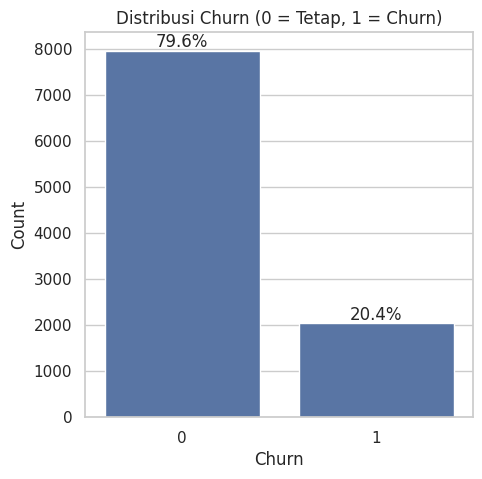

In [14]:
print(df["churn"].value_counts())

plt.figure(figsize=(5, 5))
ax = sns.countplot(data=df, x="churn")
plt.title("Distribusi Churn (0 = Tetap, 1 = Churn)")
plt.xlabel("Churn")
plt.ylabel("Count")
total = len(df)
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/total)
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom')

plt.show()

**Fitur Numerik dan Churn**

Saldo, tenor, dan fitur numerik lain dibandingkan antara nasabah churn vs tidak.

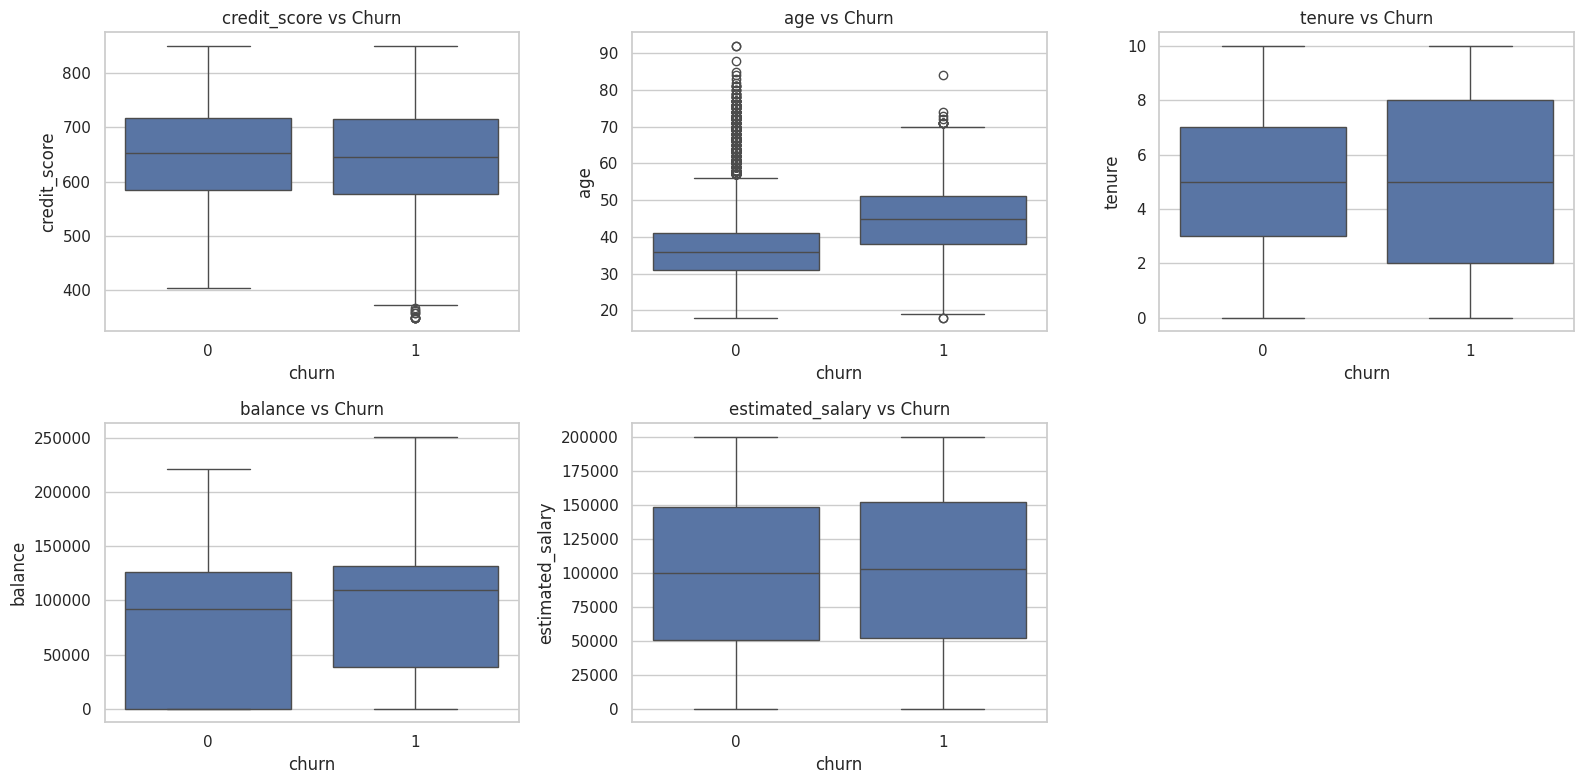

In [15]:
numerical_cols = ["credit_score", "age", "tenure", "balance", "estimated_salary"]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(numerical_cols):
    sns.boxplot(data=df, x="churn", y=col, ax=axes[i])
    axes[i].set_title(f"{col} vs Churn")
fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()

**Fitur Kategorikal vs Churn**
Produk yang digunakan (`products_number`) dan keaktifan transaksi (`active_member`) termasuk yang dicek di sini.

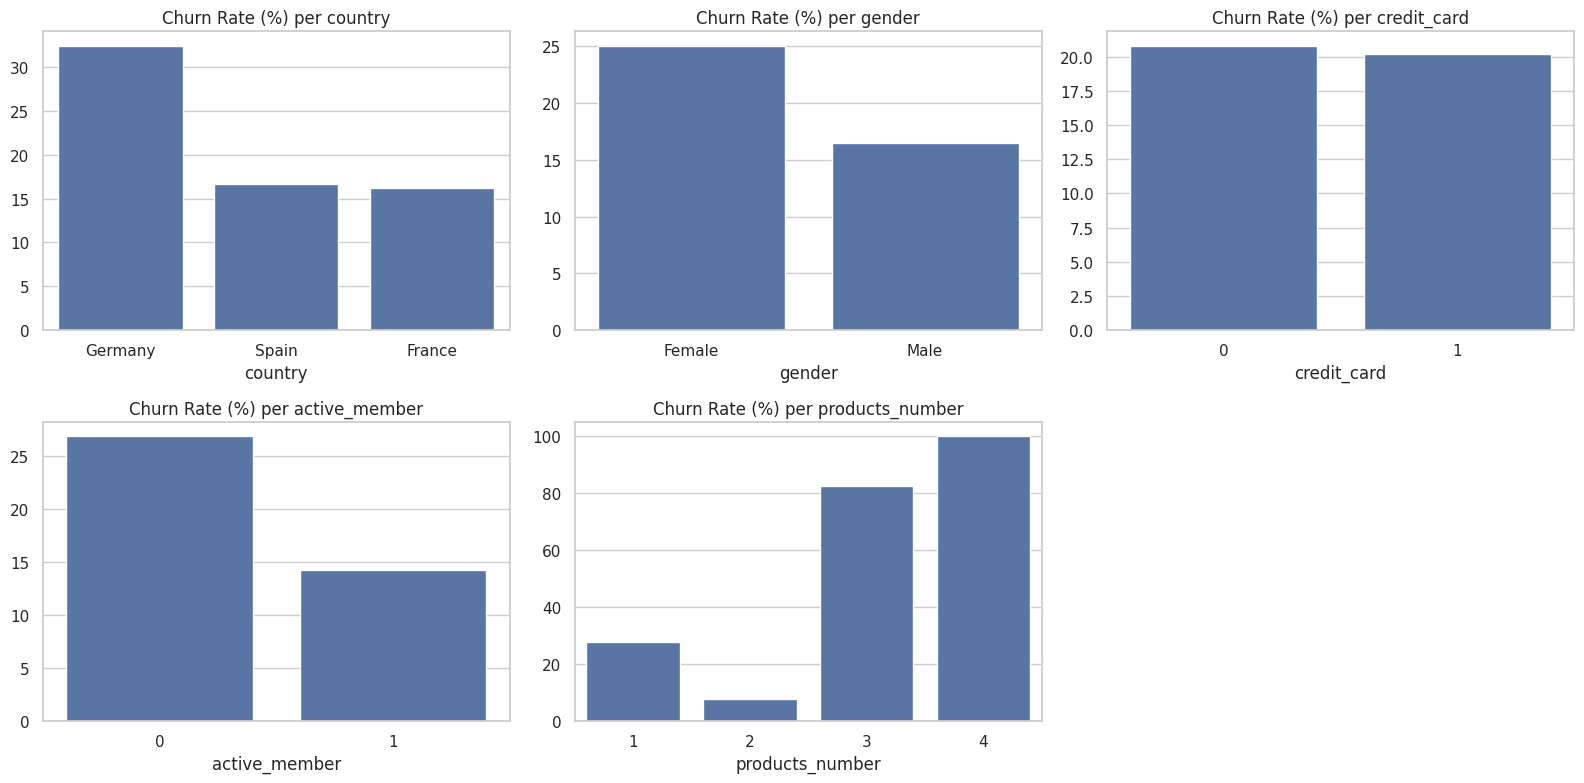

In [16]:
categorical_cols = ["country", "gender", "credit_card", "active_member", "products_number"]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(categorical_cols):
    churn_rate = df.groupby(col)["churn"].mean().sort_values(ascending=False) * 100
    sns.barplot(x=churn_rate.index, y=churn_rate.values, ax=axes[i])
    axes[i].set_title(f"Churn Rate (%) per {col}")
fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()

**Ringkasan EDA**

_berdasarkan hasil di atas, contoh:_
- Data imbalanced (~78:22) → perlu class_weight/scale_pos_weight saat training
- `age`, `country`, `active_member`, `products_number` = fitur paling berpengaruh ke churn
- `products_number` 3-4 produk → churn rate sangat tinggi (80-100%)

# Data Preprocessing

Menangani missing values, encoding variabel kategorikal, dan scaling fitur — dibungkus jadi satu Pipeline supaya bisa dipakai ulang persis sama di API nanti.

In [20]:
ID_COL = "customer_id"
TARGET_COL = "churn"
NUMERICAL_FEATURES = ["credit_score", "age", "tenure", "balance", "products_number", "estimated_salary"]
CATEGORICAL_FEATURES = ["country", "gender", "credit_card", "active_member"]

X = df[NUMERICAL_FEATURES + CATEGORICAL_FEATURES]
y = df[TARGET_COL]

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y,
)
print("Train:", X_train.shape, "| Test:", X_test.shape)


Train: (8000, 10) | Test: (2000, 10)


In [22]:
numerical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numerical_pipeline, NUMERICAL_FEATURES),
    ("cat", categorical_pipeline, CATEGORICAL_FEATURES),
])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)
print("Bentuk data setelah preprocessing:", X_train_processed.shape)


Bentuk data setelah preprocessing: (8000, 15)


In [23]:
joblib.dump(preprocessor, "preprocessor.pkl")
print("preprocessor.pkl tersimpan.")

preprocessor.pkl tersimpan.


# Model Training & Evaluation

**Pertimbangan Data Imbalanced**

Karena dataset memiliki ketidakseimbangan kelas (jumlah nasabah churn jauh lebih sedikit), maka akan menggunakan parameter `class_weight='balanced'` untuk model scikit-learn (Logistic Regression, Random Forest) dan `scale_pos_weight` untuk XGBoost. Ini membantu model memberikan bobot lebih pada kelas minoritas selama pelatihan, sehingga mencegah *bias* dan* meningkatkan kinerja prediksi* kelas minoritas.

In [24]:
# scale_pos_weight untuk XGBoost
neg_count = y_train.value_counts()[0]
pos_count = y_train.value_counts()[1]
scale_pos_weight_value = neg_count / pos_count
print(f"scale_pos_weight untuk XGBoost: {scale_pos_weight_value:.2f}")

scale_pos_weight untuk XGBoost: 3.91


### Model 1: Logistic Regression

 Logistic Regression Performance 
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1593
           1       0.39      0.70      0.50       407

    accuracy                           0.71      2000
   macro avg       0.65      0.71      0.65      2000
weighted avg       0.80      0.71      0.74      2000

ROC AUC Score: 0.7771


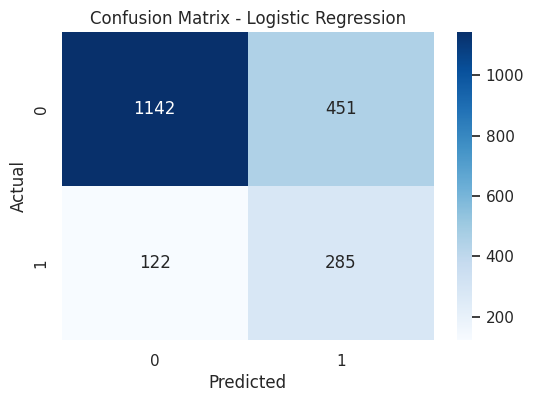

In [29]:
log_reg = LogisticRegression(random_state=42, class_weight='balanced', solver='liblinear')
log_reg.fit(X_train_processed, y_train)

y_pred_log_reg = log_reg.predict(X_test_processed)
y_prob_log_reg = log_reg.predict_proba(X_test_processed)[:, 1]

print(" Logistic Regression Performance ")
print(classification_report(y_test, y_pred_log_reg))
print(f"ROC AUC Score: {roc_auc_score(y_test, y_prob_log_reg):.4f}")

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_log_reg), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Model 2: Random Forest Classifier

 Random Forest Performance 
              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1593
           1       0.77      0.43      0.55       407

    accuracy                           0.86      2000
   macro avg       0.82      0.70      0.73      2000
weighted avg       0.85      0.86      0.84      2000

ROC AUC Score: 0.8458


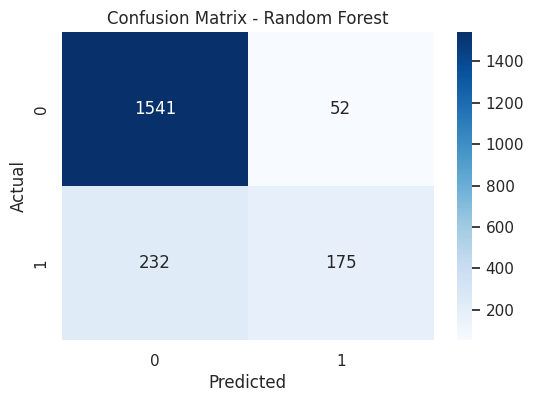

In [30]:
rf_clf = RandomForestClassifier(random_state=42, class_weight='balanced')
rf_clf.fit(X_train_processed, y_train)

y_pred_rf = rf_clf.predict(X_test_processed)
y_prob_rf = rf_clf.predict_proba(X_test_processed)[:, 1]

print(" Random Forest Performance ")
print(classification_report(y_test, y_pred_rf))
print(f"ROC AUC Score: {roc_auc_score(y_test, y_prob_rf):.4f}")

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Model 3: XGBoost Classifier

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [12:18:48] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


 XGBoost Performance 
              precision    recall  f1-score   support

           0       0.90      0.87      0.89      1593
           1       0.55      0.64      0.59       407

    accuracy                           0.82      2000
   macro avg       0.73      0.75      0.74      2000
weighted avg       0.83      0.82      0.83      2000

ROC AUC Score: 0.8299


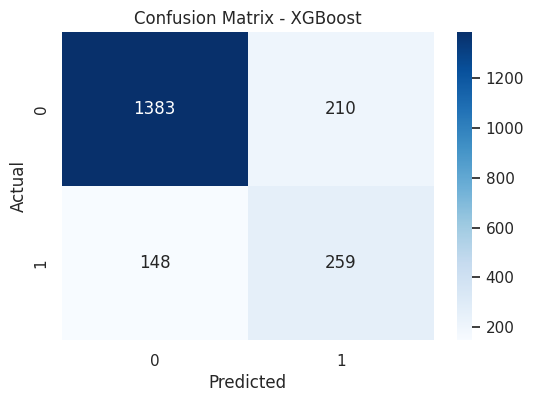

In [31]:
if XGBOOST_AVAILABLE:
    xgb_clf = XGBClassifier(random_state=42, eval_metric='logloss', use_label_encoder=False, scale_pos_weight=scale_pos_weight_value)
    xgb_clf.fit(X_train_processed, y_train)

    y_pred_xgb = xgb_clf.predict(X_test_processed)
    y_prob_xgb = xgb_clf.predict_proba(X_test_processed)[:, 1]

    print(" XGBoost Performance ")
    print(classification_report(y_test, y_pred_xgb))
    print(f"ROC AUC Score: {roc_auc_score(y_test, y_prob_xgb):.4f}")

    plt.figure(figsize=(6, 4))
    sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix - XGBoost')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
else:
    print("XGBoost tidak tersedia, model tidak dapat dilatih.")

In [39]:
models = {
    "Logistic Regression": log_reg,
    "Random Forest": rf_clf,
    "XGBoost": xgb_clf if XGBOOST_AVAILABLE else None # Pastikan XGBoost tersedia
}

# Hapus model None jika XGBoost tidak tersedia
models = {name: model for name, model in models.items() if model is not None}

results = []
trained_models = {}

for name, model in models.items():
    # Setelah Model dilatih, lalu simpan kembali di trained_models
    trained_models[name] = model

    y_pred = model.predict(X_test_processed)
    y_proba = model.predict_proba(X_test_processed)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
    })

results_df = pd.DataFrame(results).sort_values("F1-Score", ascending=False)
display(results_df.round(4))

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
2,XGBoost,0.8210,0.5522,0.6364,0.5913,0.8299
1,Random Forest,0.8580,0.7709,0.4300,0.5521,0.8458
0,Logistic Regression,0.7135,0.3872,0.7002,0.4987,0.7771


## Model Terbaik

Model terbaik: XGBoost

              precision    recall  f1-score   support

 Tidak Churn       0.90      0.87      0.89      1593
       Churn       0.55      0.64      0.59       407

    accuracy                           0.82      2000
   macro avg       0.73      0.75      0.74      2000
weighted avg       0.83      0.82      0.83      2000



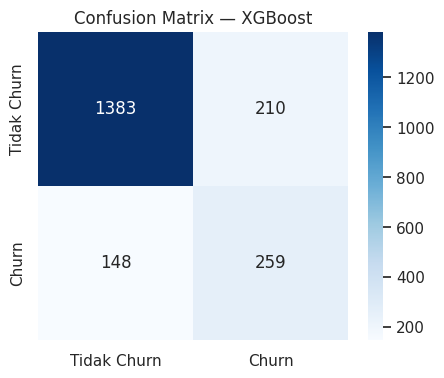

In [40]:
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]
y_pred_best = best_model.predict(X_test_processed)

print(f"Model terbaik: {best_model_name}\n")
print(classification_report(y_test, y_pred_best, target_names=["Tidak Churn", "Churn"]))

cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Tidak Churn", "Churn"], yticklabels=["Tidak Churn", "Churn"])
plt.title(f"Confusion Matrix — {best_model_name}")
plt.show()

**Simpan Model Terbaik dan Hasil Perbandingan**

In [41]:
joblib.dump(best_model, "model.pkl")
results_df.to_csv("model_comparison_results.csv", index=False)
print(f"model.pkl ({best_model_name}) tersimpan.")
print(f"model_comparison_results.csv tersimpan.")

model.pkl (XGBoost) tersimpan.
model_comparison_results.csv tersimpan.
